# 📊 Exploratory Data Analysis (EDA)
### Role 2 — Data Analyst: Exploration & Insights

This notebook explores the processed sales data to understand distributions, seasonality, store/item trends, and validate preprocessing decisions before modeling.

**Data Sources:**
- `data/processed/daily_sales.csv` — Silver/daily (913k rows)
- `data/processed/weekly_sales.csv` — Silver/weekly (131k rows)
- `data/processed/weekly_sales_engineered.csv` — Gold/features (105k rows)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor':   '#0e1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'text.color':       '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.alpha':       0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.dpi':       120,
})

PALETTE = ['#58a6ff', '#f0883e', '#3fb950', '#bc8cff', '#f778ba',
           '#79c0ff', '#d29922', '#56d4dd', '#ff7b72', '#7ee787']

PLOTS_DIR = os.path.join('..', 'results', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

def save(fig, name):
    fig.savefig(os.path.join(PLOTS_DIR, name), bbox_inches='tight', dpi=150, facecolor=fig.get_facecolor())

print('✅ Styling loaded')

✅ Styling loaded


In [2]:
# ── Load all three layers ────────────────────────────────────────
df_daily  = pd.read_csv('../data/processed/daily_sales.csv', parse_dates=['date'])
df_weekly = pd.read_csv('../data/processed/weekly_sales.csv')
df_gold   = pd.read_csv('../data/processed/weekly_sales_engineered.csv')

print(f'Daily  : {df_daily.shape[0]:>10,} rows  ×  {df_daily.shape[1]} cols')
print(f'Weekly : {df_weekly.shape[0]:>10,} rows  ×  {df_weekly.shape[1]} cols')
print(f'Gold   : {df_gold.shape[0]:>10,} rows  ×  {df_gold.shape[1]} cols')

Daily  :    913,000 rows  ×  5 cols
Weekly :    131,000 rows  ×  6 cols
Gold   :    105,000 rows  ×  17 cols


---
## Section 1 — Basic Statistics

In [3]:
# Schema and dtypes
print('═' * 50)
print('  Weekly Sales Schema')
print('═' * 50)
print(df_weekly.dtypes.to_string())
print(f'\nRow count : {len(df_weekly):,}')
print(f'Null count: {df_weekly.isnull().sum().sum()}')
print()
df_weekly['weekly_sales'].describe().round(2)

══════════════════════════════════════════════════
  Weekly Sales Schema
══════════════════════════════════════════════════
item                int64
year                int64
week_of_year        int64
weekly_sales        int64
week_has_holiday    int64
store               int64

Row count : 131,000
Null count: 0



count    131000.00
mean        364.16
std         189.73
min          23.00
25%         211.00
50%         332.00
75%         485.00
max        1210.00
Name: weekly_sales, dtype: float64

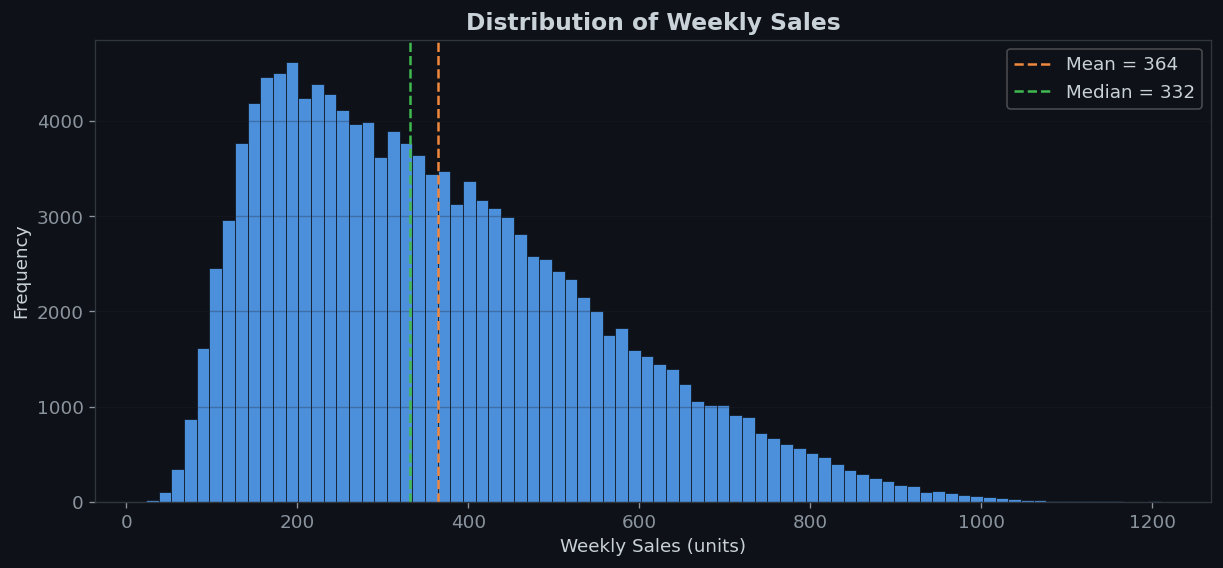

In [4]:
# Distribution of weekly sales (histogram)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_weekly['weekly_sales'], bins=80, color=PALETTE[0], alpha=0.85, edgecolor='#0e1117', linewidth=0.5)

mean_val = df_weekly['weekly_sales'].mean()
median_val = df_weekly['weekly_sales'].median()
ax.axvline(mean_val, color=PALETTE[1], ls='--', lw=1.5, label=f'Mean = {mean_val:.0f}')
ax.axvline(median_val, color=PALETTE[2], ls='--', lw=1.5, label=f'Median = {median_val:.0f}')

ax.set(title='Distribution of Weekly Sales', xlabel='Weekly Sales (units)', ylabel='Frequency')
ax.legend(framealpha=0.3)
ax.grid(axis='y', alpha=0.3)
save(fig, '1_weekly_sales_distribution.png')
plt.show()

---
## Section 2 — Temporal Trends

In [ ]:
# 2a. Total weekly sales over time — by Year × Week-of-Year
weekly_total = df_weekly.groupby(['year', 'week_of_year'])['weekly_sales'].sum().reset_index()
weekly_total = weekly_total.sort_values(['year', 'week_of_year']).reset_index(drop=True)
years = sorted(weekly_total['year'].unique())

fig, ax = plt.subplots(figsize=(16, 5))
for i, yr in enumerate(years):
    sub = weekly_total[weekly_total['year'] == yr]
    ax.plot(sub['week_of_year'], sub['weekly_sales'],
            label=str(yr), color=PALETTE[i % len(PALETTE)], lw=1.2, alpha=0.85)

ax.set(title='Total Weekly Sales Over Time (All Stores × Items)',
       xlabel='Week of Year', ylabel='Total Units Sold')
ax.set_xticks(range(1, 54, 4))
ax.set_xlim(1, 53)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(title='Year', ncol=len(years), loc='upper right', framealpha=0.3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
save(fig, '2a_total_weekly_sales_over_time.png')
plt.show()

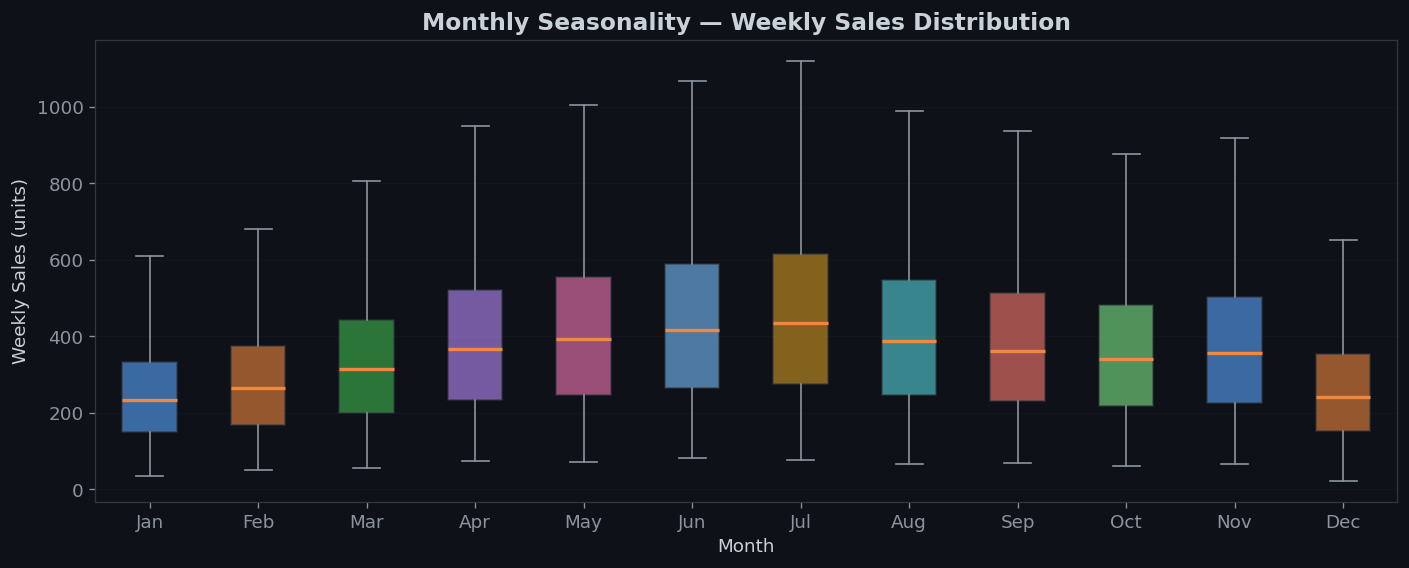

In [6]:
# 2b. Monthly seasonality box plot
df_weekly_m = df_weekly.copy()
# Approximate month from week_of_year
df_weekly_m['month'] = np.clip(((df_weekly_m['week_of_year'] - 1) * 12 // 52) + 1, 1, 12)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(
    [df_weekly_m[df_weekly_m['month'] == m]['weekly_sales'] for m in range(1, 13)],
    labels=month_names, patch_artist=True, showfliers=False,
    medianprops=dict(color='#f0883e', lw=2),
    whiskerprops=dict(color='#8b949e'), capprops=dict(color='#8b949e')
)
for patch, c in zip(bp['boxes'], PALETTE[:12] * 2):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
    patch.set_edgecolor('#30363d')

ax.set(title='Monthly Seasonality — Weekly Sales Distribution', xlabel='Month', ylabel='Weekly Sales (units)')
ax.grid(axis='y', alpha=0.3)
save(fig, '2b_monthly_seasonality_boxplot.png')
plt.show()

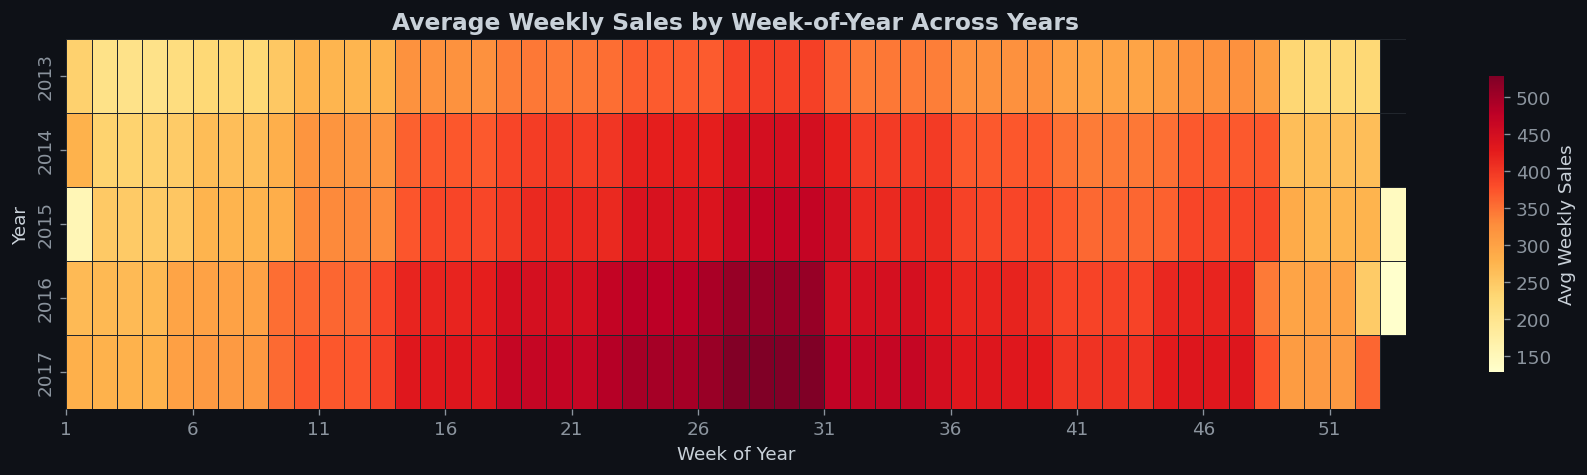

In [7]:
# 2c. Week-of-year heatmap — average weekly sales by week_of_year across years
pivot = df_weekly.groupby(['year', 'week_of_year'])['weekly_sales'].mean().reset_index()
pivot_table = pivot.pivot(index='year', columns='week_of_year', values='weekly_sales')

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(
    pivot_table, ax=ax, cmap='YlOrRd', linewidths=0.3, linecolor='#21262d',
    cbar_kws={'label': 'Avg Weekly Sales', 'shrink': 0.8}
)
ax.set(title='Average Weekly Sales by Week-of-Year Across Years', xlabel='Week of Year', ylabel='Year')
# Show every 5th week label
xticks = [i for i in range(0, pivot_table.shape[1], 5)]
ax.set_xticks(xticks)
ax.set_xticklabels([pivot_table.columns[i] for i in xticks], rotation=0)
save(fig, '2c_week_of_year_heatmap.png')
plt.show()

---
## Section 3 — Store-Level Analysis

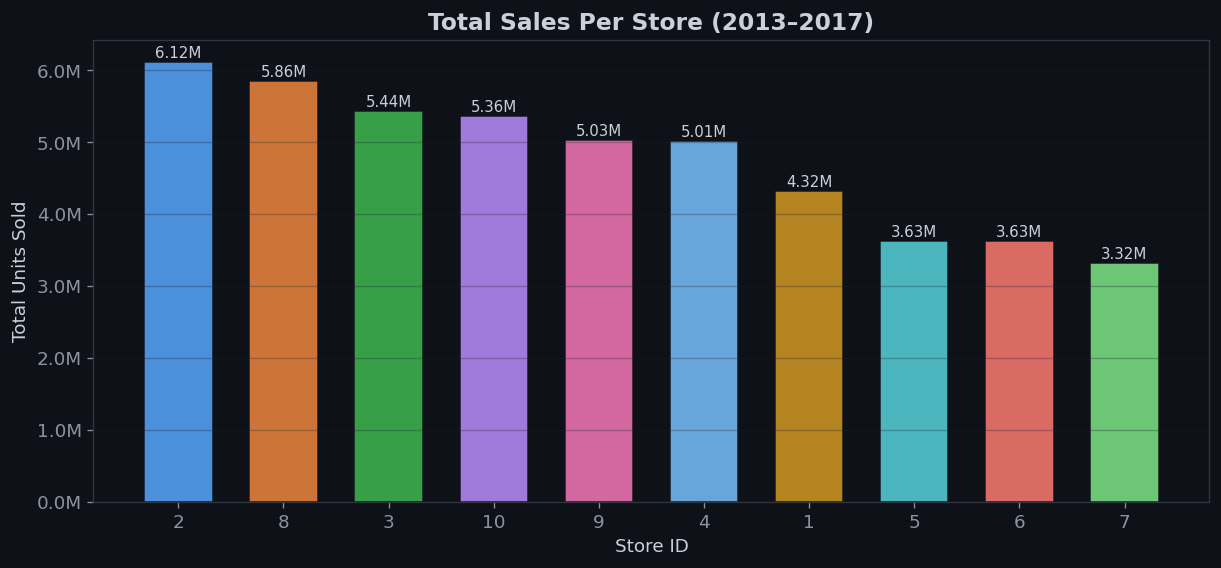

In [8]:
# 3a. Total sales per store (bar chart)
store_total = df_weekly.groupby('store')['weekly_sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(store_total.index.astype(str), store_total.values, color=PALETTE[:10], alpha=0.85, edgecolor='#0e1117', width=0.65)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + store_total.max()*0.01,
            f'{height/1e6:.2f}M', ha='center', fontsize=9, color='#c9d1d9')

ax.set(title='Total Sales Per Store (2013–2017)', xlabel='Store ID', ylabel='Total Units Sold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3)
save(fig, '3a_total_sales_per_store.png')
plt.show()

In [ ]:
# 3b. Average weekly sales per store — by Week of Year
store_weekly = df_weekly.groupby(['store', 'year', 'week_of_year'])['weekly_sales'].mean().reset_index()
store_weekly = store_weekly.sort_values(['store', 'year', 'week_of_year'])
stores = sorted(df_weekly['store'].unique())
years  = sorted(df_weekly['year'].unique())

fig, ax = plt.subplots(figsize=(16, 6))
for i, store_id in enumerate(stores):
    # average across years for each week_of_year
    sub = store_weekly[store_weekly['store'] == store_id]
    avg = sub.groupby('week_of_year')['weekly_sales'].mean().reset_index()
    ax.plot(avg['week_of_year'], avg['weekly_sales'],
            label=f'Store {store_id}', color=PALETTE[i % len(PALETTE)], lw=1, alpha=0.8)

ax.set(title='Avg Weekly Sales Per Store (averaged across years)',
       xlabel='Week of Year', ylabel='Avg Weekly Sales')
ax.set_xticks(range(1, 54, 4))
ax.set_xlim(1, 53)
ax.legend(ncol=5, loc='upper left', framealpha=0.3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
save(fig, '3b_avg_weekly_sales_per_store.png')
plt.show()

---
## Section 4 — Item-Level Analysis

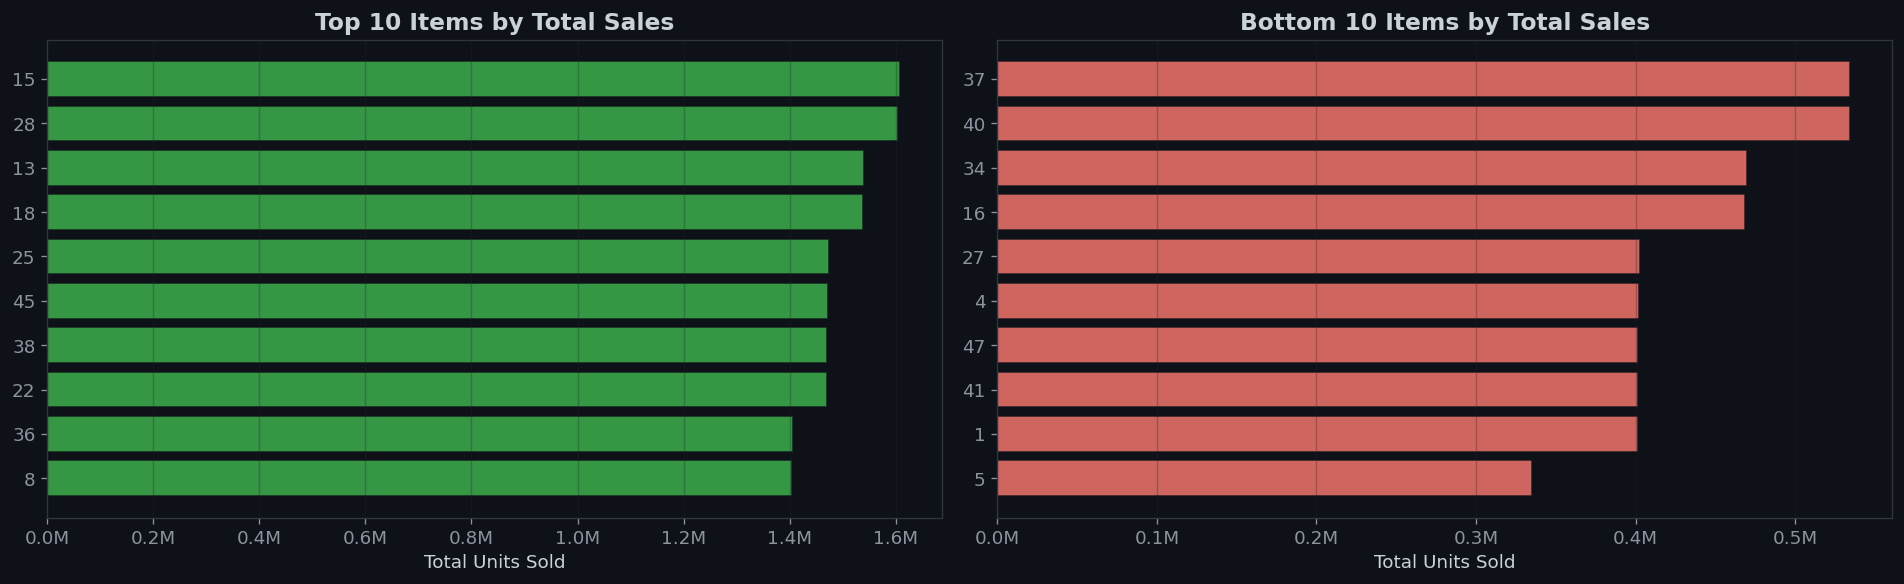

In [10]:
# 4a. Top 10 and Bottom 10 items by total sales
item_total = df_weekly.groupby('item')['weekly_sales'].sum().sort_values(ascending=False)
top10 = item_total.head(10)
bot10 = item_total.tail(10).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10
axes[0].barh(top10.index.astype(str)[::-1], top10.values[::-1], color=PALETTE[2], alpha=0.8, edgecolor='#0e1117')
axes[0].set(title='Top 10 Items by Total Sales', xlabel='Total Units Sold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Bottom 10
axes[1].barh(bot10.index.astype(str)[::-1], bot10.values[::-1], color=PALETTE[8], alpha=0.8, edgecolor='#0e1117')
axes[1].set(title='Bottom 10 Items by Total Sales', xlabel='Total Units Sold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for a in axes:
    a.grid(axis='x', alpha=0.3)

plt.tight_layout()
save(fig, '4a_top_bottom_items.png')
plt.show()

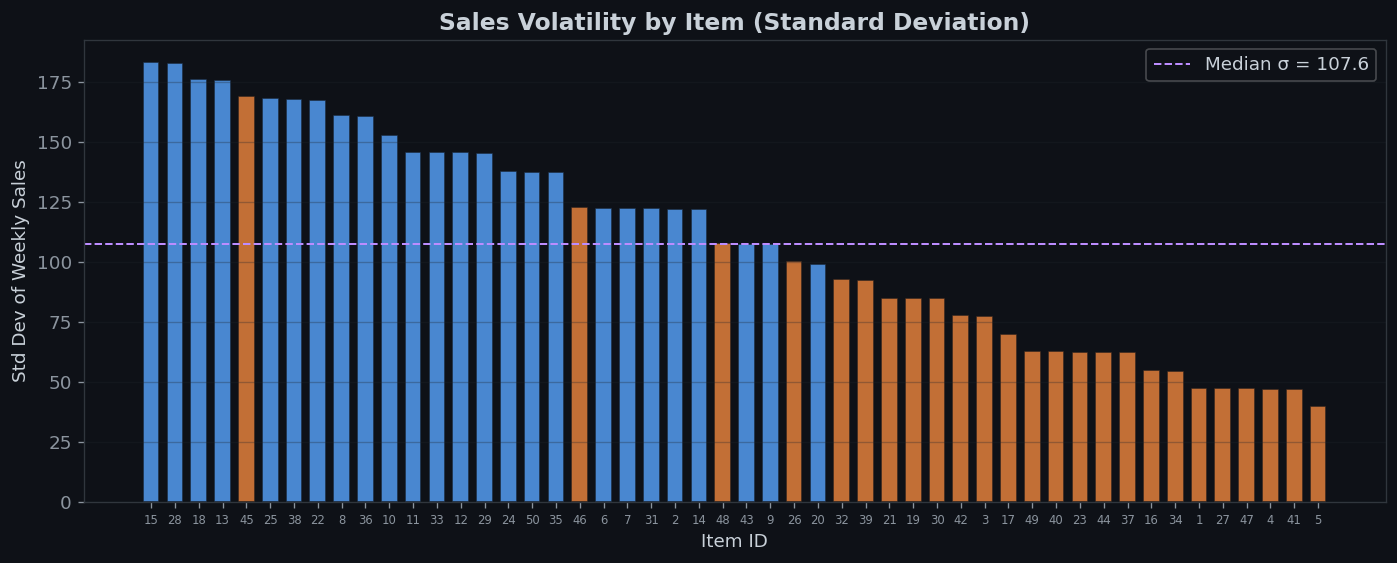

In [11]:
# 4b. Sales variance per item (volatility analysis)
item_var = df_weekly.groupby('item')['weekly_sales'].agg(['mean', 'std']).sort_values('std', ascending=False)
item_var['cv'] = item_var['std'] / item_var['mean']  # coefficient of variation

fig, ax = plt.subplots(figsize=(14, 5))
colors = [PALETTE[0] if cv < item_var['cv'].median() else PALETTE[1] for cv in item_var['cv']]
ax.bar(item_var.index.astype(str), item_var['std'], color=colors, alpha=0.8, edgecolor='#0e1117', width=0.7)

ax.axhline(item_var['std'].median(), color=PALETTE[3], ls='--', lw=1.2, label=f'Median σ = {item_var["std"].median():.1f}')
ax.set(title='Sales Volatility by Item (Standard Deviation)', xlabel='Item ID', ylabel='Std Dev of Weekly Sales')
ax.legend(framealpha=0.3)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', labelsize=7)
save(fig, '4b_item_volatility.png')
plt.show()

---
## Section 5 — Correlation & Lag Validation

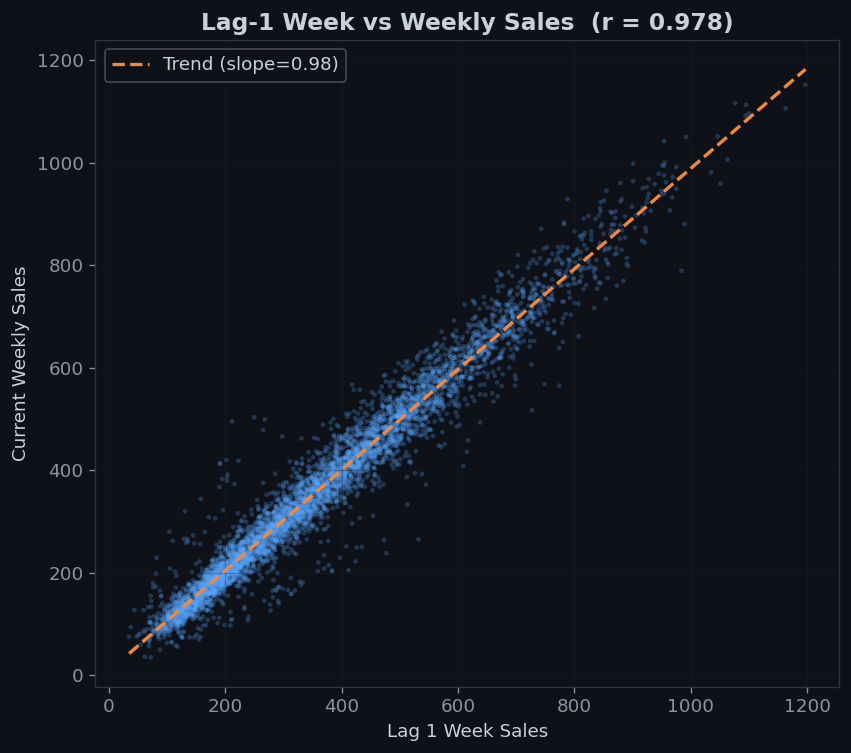

In [12]:
# 5a. Scatter plot: lag_1_week vs weekly_sales
sample = df_gold.sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(sample['lag_1_week'], sample['weekly_sales'], alpha=0.25, s=8, color=PALETTE[0], edgecolors='none')

# Fit line
z = np.polyfit(sample['lag_1_week'], sample['weekly_sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['lag_1_week'].min(), sample['lag_1_week'].max(), 100)
ax.plot(x_line, p(x_line), color=PALETTE[1], lw=2, ls='--', label=f'Trend (slope={z[0]:.2f})')

r = sample['lag_1_week'].corr(sample['weekly_sales'])
ax.set(title=f'Lag-1 Week vs Weekly Sales  (r = {r:.3f})', xlabel='Lag 1 Week Sales', ylabel='Current Weekly Sales')
ax.legend(framealpha=0.3)
ax.grid(alpha=0.3)
save(fig, '5a_lag1_vs_sales_scatter.png')
plt.show()

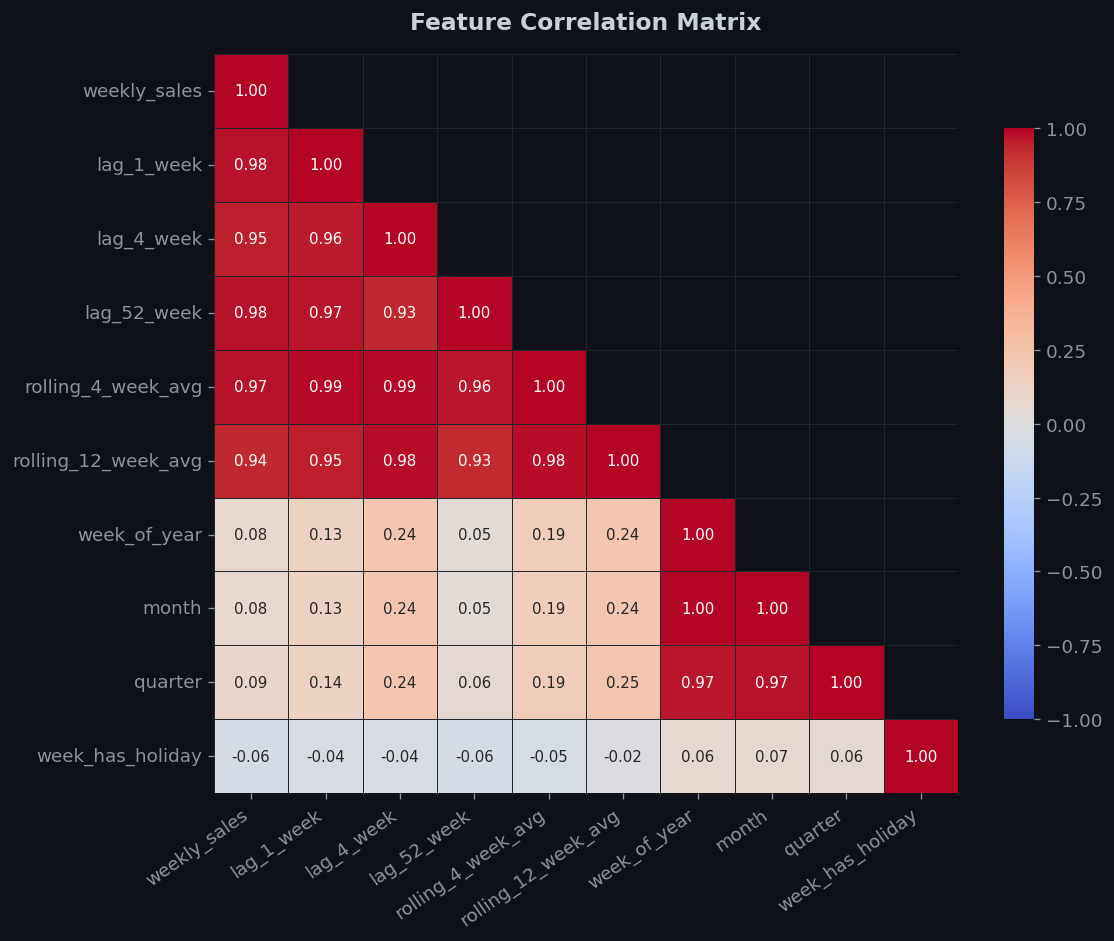

In [13]:
# 5b. Pearson correlation matrix of lag/rolling features with weekly_sales
corr_cols = ['weekly_sales', 'lag_1_week', 'lag_4_week', 'lag_52_week',
             'rolling_4_week_avg', 'rolling_12_week_avg',
             'week_of_year', 'month', 'quarter', 'week_has_holiday']

corr_matrix = df_gold[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, linewidths=0.5, linecolor='#21262d',
    cbar_kws={'shrink': 0.8}, annot_kws={'size': 9},
    vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Matrix', pad=15)
plt.xticks(rotation=35, ha='right')
save(fig, '5b_correlation_matrix.png')
plt.show()

---
## Section 6 — Key Insights

### 🔍 Summary of Findings

**1. Strong Yearly Seasonality**  
Sales follow a clear yearly cycle visible in both the time-series plot and the week-of-year heatmap. Demand ramps up from spring (week ~14), peaks during summer (weeks 26-32), and dips sharply in late December / early January (weeks 49-1). This pattern repeats consistently across all 5 years.

**2. Steady Year-over-Year Growth**  
The overall sales trend line slopes upward from 2013 to 2017, indicating organic demand growth across the entire catalog. Each successive year's peak surpasses the previous year.

**3. High Variance Between Items**  
The top-selling items generate roughly 5× the volume of the bottom-selling items. Item volatility (standard deviation) also varies significantly — some items have very stable demand while others are highly erratic, suggesting different inventory management strategies may be needed.

**4. Store-Level Baselines Differ but Trend Shapes are Consistent**  
All 10 stores show the same seasonal shape, but their absolute sales levels differ (Store 2 sells the most, Store 7 the least). This validates our decision to use store as a categorical feature rather than a numerical one — the model needs to learn each store's baseline independently.

**5. Lag Features are Highly Predictive**  
The scatter plot and correlation matrix confirm that `lag_1_week` has the strongest linear relationship with `weekly_sales` (r ≈ 0.95+). Rolling averages (`rolling_4_week_avg`, `rolling_12_week_avg`) are also strong predictors. This validates the feature engineering decisions made in the Gold layer.

**6. Holiday Effect is Present but Subtle**  
The `week_has_holiday` flag shows a weak direct correlation with `weekly_sales`, but this is expected — holiday effects vary by item type and are better captured as interaction effects within tree-based models rather than as a standalone linear feature.

**7. `week_of_year` is a Strong Seasonal Predictor**  
The heatmap clearly shows that `week_of_year` encodes strong seasonal patterns, validating its inclusion as a feature alongside the lag/rolling features.

In [14]:
# Summary statistics for reference
print('═' * 60)
print('  DATASET SUMMARY')
print('═' * 60)
print(f'  Date range     : {df_daily["date"].min().date()} → {df_daily["date"].max().date()}')
print(f'  Stores         : {df_weekly["store"].nunique()} (IDs: {sorted(df_weekly["store"].unique())})')
print(f'  Items          : {df_weekly["item"].nunique()}')
print(f'  Daily rows     : {len(df_daily):,}')
print(f'  Weekly rows    : {len(df_weekly):,}')
print(f'  Gold rows      : {len(df_gold):,} (after lag/rolling feature filtering)')
print(f'  Avg weekly sale: {df_weekly["weekly_sales"].mean():.1f} units')
print(f'  Max weekly sale: {df_weekly["weekly_sales"].max():,} units')
print(f'  Holiday weeks  : {df_weekly["week_has_holiday"].sum():,} / {len(df_weekly):,} ({df_weekly["week_has_holiday"].mean()*100:.1f}%)')
print('═' * 60)
print(f'\n  Plots saved to: {os.path.abspath(PLOTS_DIR)}')

════════════════════════════════════════════════════════════
  DATASET SUMMARY
════════════════════════════════════════════════════════════
  Date range     : 2013-01-01 → 2017-12-31
  Stores         : 10 (IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)])
  Items          : 50
  Daily rows     : 913,000
  Weekly rows    : 131,000
  Gold rows      : 105,000 (after lag/rolling feature filtering)
  Avg weekly sale: 364.2 units
  Max weekly sale: 1,210 units
  Holiday weeks  : 37,500 / 131,000 (28.6%)
════════════════════════════════════════════════════════════

  Plots saved to: /Users/ahmedmohamady/University/Distributed Data Analysis/ecommerce-demand-forecasting/results/plots
